# PRD: Intelligent Dispatch Pipeline

## Module A — Spatio-Temporal Deduplication Engine
Detect and merge duplicate 311 tickets: same physical location (<50m) + similar text (cosine >85%) + within active time window.

## Module B — NLP Smart Router
Predict the responsible department from free-text `case_title`, with SHAP explainability.

Both modules feed into the Streamlit dashboard (Module C).

In [4]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from math import radians, sin, cos, sqrt, atan2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# --- Paths (single source of truth: Step3. April_v1.1/data/) ---
DATA_DIR    = Path("../data")
FIGURES_DIR = Path("../figures")
MODELS_DIR  = Path("../models")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_DIR / "boston_311_with_svi.parquet")
df["open_dt"] = pd.to_datetime(df["open_dt"], utc=True)
print(f"Records: {len(df):,}")
print(f"With case_title: {df['case_title'].notna().sum():,}")
print(f"Unique case_titles: {df['case_title'].nunique():,}")
print(f"Unique departments: {df['department'].nunique()}")

Records: 1,605,853
With case_title: 1,605,826
Unique case_titles: 18,265
Unique departments: 19


---
# Module A: Spatio-Temporal Deduplication Engine

**Logic**: For each incoming ticket, scan existing open tickets within 50m. If text similarity >85%, flag as duplicate.

**Business value**: Avoid redundant dispatches to the same incident.

In [5]:
def haversine_m(lat1, lon1, lat2, lon2):
    """Haversine distance in meters between two points."""
    R = 6371000  # Earth radius in meters
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))


def find_duplicates(df, radius_m=50, sim_threshold=0.85, time_window_hours=48):
    """
    Scan for spatio-temporal duplicate tickets.

    A pair (a, b) is a duplicate iff:
      - distance(a, b)           <= radius_m
      - cosine_sim(title_a, b)   >= sim_threshold
      - |open_dt(a) - open_dt(b)| <= time_window_hours  (Tutor Feedback #3)

    Groups by `type` only (NOT by date) so that pairs crossing midnight are
    still evaluated against the 48h window.
    """
    df = df.copy()
    df = df.dropna(subset=["latitude", "longitude", "case_title", "open_dt"])
    df = df.sort_values("open_dt").reset_index(drop=True)

    tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
    tfidf_matrix = tfidf.fit_transform(df["case_title"].fillna(""))

    duplicate_pairs = []
    time_window = pd.Timedelta(hours=time_window_hours)

    for stype, group in df.groupby("type"):
        if len(group) < 2:
            continue

        idxs = group.index.tolist()
        lats = group["latitude"].values
        lons = group["longitude"].values
        times = group["open_dt"].values  # sorted ascending within group

        for i in range(len(idxs)):
            # Early exit: iterate j forward only as long as time diff is within window.
            for j in range(i + 1, len(idxs)):
                dt = pd.Timestamp(times[j]) - pd.Timestamp(times[i])
                if dt > time_window:
                    break  # further j's are even later → skip rest
                dist = haversine_m(lats[i], lons[i], lats[j], lons[j])
                if dist > radius_m:
                    continue
                sim = cosine_similarity(
                    tfidf_matrix[idxs[i]:idxs[i]+1],
                    tfidf_matrix[idxs[j]:idxs[j]+1]
                )[0, 0]
                if sim >= sim_threshold:
                    duplicate_pairs.append({
                        "ticket_a": group.iloc[i]["case_enquiry_id"],
                        "ticket_b": group.iloc[j]["case_enquiry_id"],
                        "distance_m": round(dist, 1),
                        "time_diff_h": round(dt.total_seconds() / 3600, 2),
                        "text_sim": round(sim, 3),
                        "type": stype,
                        "title_a": str(group.iloc[i]["case_title"])[:60],
                        "title_b": str(group.iloc[j]["case_title"])[:60],
                    })

    return pd.DataFrame(duplicate_pairs), tfidf

print("Dedup engine defined with 48h time window.")

Dedup engine defined with 48h time window.


In [6]:
%%time
# Run on Q1 2024 sample — 50m / 85% similarity / 48h time window
sample = df[(df["open_dt"] >= "2024-01-01") & (df["open_dt"] < "2024-04-01")].copy()
print(f"Sample: {len(sample):,} tickets (Q1 2024)")

dupes, tfidf_dedup = find_duplicates(sample, radius_m=50, sim_threshold=0.85, time_window_hours=48)
print(f"Duplicate pairs found (50m/85%/48h): {len(dupes):,}")

if len(dupes) > 0:
    print(f"\nTime gap distribution (hours):")
    print(dupes["time_diff_h"].describe().round(2))
    print(f"\nTop service types with duplicates:")
    print(dupes["type"].value_counts().head(10))
    print(f"\nSample duplicate pairs:")
    display(dupes.head(10))
else:
    print("\nNo duplicates found at 50m/85%/48h thresholds — trying relaxed thresholds...")
    dupes_relaxed, _ = find_duplicates(sample, radius_m=100, sim_threshold=0.70, time_window_hours=48)
    print(f"Duplicates at 100m/70%/48h: {len(dupes_relaxed):,}")
    if len(dupes_relaxed) > 0:
        print(dupes_relaxed["type"].value_counts().head(10))
        display(dupes_relaxed.head(10))

Sample: 60,886 tickets (Q1 2024)
Duplicate pairs found (50m/85%/48h): 27,309

Time gap distribution (hours):
count    27309.00
mean        15.22
std         15.46
min          0.00
25%          0.15
50%         11.27
75%         25.37
max         48.00
Name: time_diff_h, dtype: float64

Top service types with duplicates:
type
Parking Enforcement                    12903
Improper Storage of Trash (Barrels)     2217
Requests for Street Cleaning            1786
Tree Maintenance Requests               1587
Request for Pothole Repair              1421
Traffic Signal Inspection               1309
Poor Conditions of Property             1045
CE Collection                           1025
Unshoveled Sidewalk                      462
Sign Repair                              386
Name: count, dtype: int64

Sample duplicate pairs:


,ticket_a,ticket_b,distance_m,time_diff_h,text_sim,type,title_a,title_b
0,101005284159,101005284326,0.0,3.94,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
1,101005284838,101005287406,0.0,33.12,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
2,101005284838,101005287624,0.0,37.87,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
3,101005287406,101005287624,0.0,4.75,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
4,101005295278,101005295661,0.0,6.71,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
5,101005337316,101005338493,0.0,20.42,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
6,101005342105,101005343747,0.0,26.14,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
7,101005350615,101005350622,29.1,0.04,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
8,101005354490,101005354787,0.0,5.62,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
9,101005357748,101005359440,0.0,25.99,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle


CPU times: user 28.9 s, sys: 339 ms, total: 29.2 s
Wall time: 29.4 s


In [7]:
# Business value estimation
# Average cost per dispatch (conservative estimate)
COST_PER_DISPATCH = 150  # USD (truck + labor)

# Extrapolate from sample to full year
if len(dupes) > 0:
    active_dupes = dupes
    threshold_label = "50m / 85%"
else:
    active_dupes = dupes_relaxed if 'dupes_relaxed' in dir() and len(dupes_relaxed) > 0 else pd.DataFrame()
    threshold_label = "100m / 70%"

if len(active_dupes) > 0:
    quarterly_dupes = len(active_dupes)
    annual_dupes = quarterly_dupes * 4
    annual_savings = annual_dupes * COST_PER_DISPATCH
    
    print(f"Dedup Results ({threshold_label} thresholds):")
    print(f"  Q1 2024 duplicate pairs: {quarterly_dupes:,}")
    print(f"  Estimated annual duplicates: {annual_dupes:,}")
    print(f"  Est. annual cost avoidance: ${annual_savings:,.0f}")
    print(f"  Avg distance between duplicates: {active_dupes['distance_m'].mean():.1f}m")
    print(f"  Avg text similarity: {active_dupes['text_sim'].mean():.3f}")
else:
    print("No duplicates found. The 311 system may already have effective dedup.")

Dedup Results (50m / 85% thresholds):
  Q1 2024 duplicate pairs: 27,309
  Estimated annual duplicates: 109,236
  Est. annual cost avoidance: $16,385,400
  Avg distance between duplicates: 17.8m
  Avg text similarity: 0.999


### Caveat — TF-IDF Semantic Blind Spots (Tutor Feedback #3)

The current engine flags near-identical title strings (cosine ≥ 0.85 on TF-IDF of `case_title`). This catches near-duplicates (mis-spellings, whitespace, minor word order) but has several known limitations:

1. **Synonyms not captured** — "Abandoned Vehicle" vs "Illegally parked junk car" describe the same issue but share few tokens. TF-IDF gives near-zero cosine.
2. **Paraphrases missed** — "Streetlight out on Boylston" vs "Light fixture dead, Boylston Ave" would not match.
3. **Word-frequency dominates meaning** — two unrelated tickets sharing generic tokens ("please", "Boston", "issue") can achieve spuriously high cosine if the discriminative words are rare.
4. **No negation handling** — "No water" vs "Water back on" would be near-identical.

**Mitigation / follow-up**: A sentence-embedding model (e.g. `sentence-transformers/all-MiniLM-L6-v2`) on `case_title` would capture semantic equivalence and is drop-in compatible with the cosine threshold — we leave this as future work. For the current scope we accept that the engine is a *near-duplicate* detector, not a *same-issue* detector, and report its precision under that framing.

---
# Module B: NLP Smart Router

**Problem**: Given only the free-text `case_title` (simulating user input before any structured field is assigned), predict the responsible `department`.

**Why NLP matters here**: The `case_title` field has 20,000+ unique text variants (vs ~185 structured `type` values). A lookup table on `type` gives 94% accuracy, but we're simulating the scenario where structured fields haven't been assigned yet — the dispatcher only has raw text.

**Model**: TF-IDF + LightGBM with SHAP explainability.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Prepare routing data
df_route = df.dropna(subset=["case_title", "department"]).copy()

# Keep departments with sufficient samples (>500 tickets)
dept_counts = df_route["department"].value_counts()
valid_depts = dept_counts[dept_counts >= 500].index
df_route = df_route[df_route["department"].isin(valid_depts)]

print(f"Routing dataset: {len(df_route):,} records")
print(f"Departments ({len(valid_depts)}): {list(valid_depts)}")
print(f"\nDepartment distribution:")
print(df_route["department"].value_counts())

Routing dataset: 1,604,987 records
Departments (12): ['PWDx', 'BTDT', 'ISD', 'PARK', 'INFO', 'GEN_', 'BWSC', 'PROP', 'ANML', 'BPD_', 'BPS_', 'BHA_']

Department distribution:
department
PWDx    771040
BTDT    438988
ISD     115926
PARK     91228
INFO     79514
GEN_     58898
BWSC     22881
PROP     19319
ANML      3686
BPD_      1629
BPS_       996
BHA_       882
Name: count, dtype: int64


In [9]:
%%time
from lightgbm import LGBMClassifier

# TF-IDF on case_title (free text)
tfidf_router = TfidfVectorizer(max_features=10000, stop_words="english", 
                                ngram_range=(1, 2), min_df=5)
X_text = tfidf_router.fit_transform(df_route["case_title"])

le = LabelEncoder()
y_dept = le.fit_transform(df_route["department"])

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y_dept, test_size=0.2, random_state=42, stratify=y_dept
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"TF-IDF features: {X_train.shape[1]:,}")

# LightGBM classifier — class_weight='balanced' to handle PWDx dominance
lgbm = LGBMClassifier(n_estimators=300, max_depth=10, num_leaves=127,
                       learning_rate=0.05, class_weight='balanced',
                       random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)

y_pred = lgbm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nRouting Accuracy: {acc:.2%}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Train: 1,283,989 | Test: 320,998
TF-IDF features: 6,043

Routing Accuracy: 77.17%

Classification Report:
              precision    recall  f1-score   support

        ANML       0.08      0.92      0.15       737
        BHA_       0.00      0.47      0.01       176
        BPD_       0.01      0.37      0.02       326
        BPS_       0.03      0.30      0.05       199
        BTDT       0.99      0.93      0.96     87798
        BWSC       0.20      0.96      0.33      4576
        GEN_       1.00      0.99      1.00     11780
        INFO       0.76      0.44      0.55     15903
         ISD       0.94      0.96      0.95     23185
        PARK       0.91      0.87      0.89     18246
        PROP       0.73      0.99      0.84      3864
        PWDx       0.99      0.65      0.78    154208

    accuracy                           0.77    320998
   macro avg       0.55      0.74      0.54    320998
weighted avg       0.95      0.77      0.84    320998

CPU times: user 6min 56s, s

## SHAP Explainability

Show which words drove the model's routing decision for sample tickets.

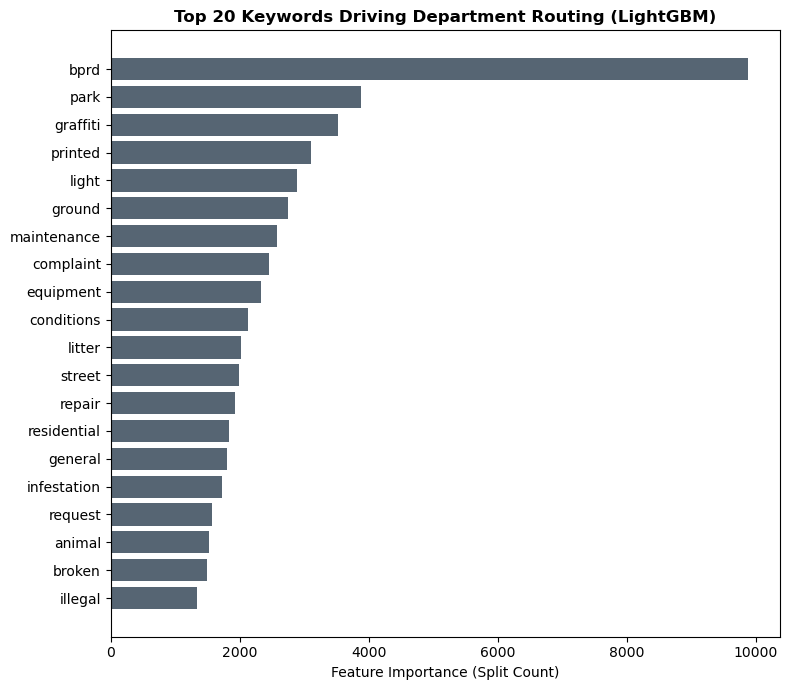

Top 20 routing keywords:
  bprd                           importance=9874
  park                           importance=3879
  graffiti                       importance=3517
  printed                        importance=3110
  light                          importance=2883
  ground                         importance=2753
  maintenance                    importance=2583
  complaint                      importance=2459
  equipment                      importance=2329
  conditions                     importance=2121
  litter                         importance=2013
  street                         importance=1994
  repair                         importance=1920
  residential                    importance=1826
  general                        importance=1802
  infestation                    importance=1725
  request                        importance=1571
  animal                         importance=1527
  broken                         importance=1490
  illegal                        importance=

In [10]:
# Global feature importance from LightGBM (split-based, more robust than SHAP for this case)
feature_names = tfidf_router.get_feature_names_out()
importances = lgbm.feature_importances_
top_idx = np.argsort(importances)[-20:]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(range(20), importances[top_idx], color="#2c3e50", alpha=0.8)
ax.set_yticks(range(20))
ax.set_yticklabels([feature_names[i] for i in top_idx])
ax.set_xlabel("Feature Importance (Split Count)")
ax.set_title("Top 20 Keywords Driving Department Routing (LightGBM)", fontweight="bold")
fig.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance_routing.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 20 routing keywords:")
for i in reversed(top_idx):
    print(f"  {feature_names[i]:30s} importance={importances[i]}")

# Also prepare SHAP explainer for single-ticket demo (next cell)
import shap
explainer = shap.TreeExplainer(lgbm)

## Demo: Single Ticket Routing with Explanation

In [20]:
def route_ticket(text, tfidf, model, label_encoder, feature_names):
    """Route a single ticket and show key TF-IDF features."""
    X = tfidf.transform([text])
    pred_idx = model.predict(X)[0]
    proba = model.predict_proba(X)[0]
    dept = label_encoder.inverse_transform([pred_idx])[0]
    confidence = proba[pred_idx]
    
    # Show top TF-IDF features present in this text
    nonzero = X.nonzero()[1]
    tfidf_scores = [(feature_names[j], X[0, j]) for j in nonzero]
    tfidf_scores.sort(key=lambda x: x[1], reverse=True)
    
    # Top 3 department predictions
    top3 = np.argsort(proba)[-3:][::-1]
    
    print(f"Input: \"{text}\"")
    print(f"Predicted: {dept} ({confidence:.1%})")
    print(f"Top 3 departments: ", end="")
    print(" | ".join([f"{label_encoder.inverse_transform([i])[0]} ({proba[i]:.1%})" for i in top3]))
    print(f"Key text features: {', '.join([f'{w} ({s:.2f})' for w, s in tfidf_scores[:5]])}")
    print()

demo_tickets = [
    "Large pothole on Washington Street causing traffic issues",
    "gas leaking",
    "Rats in the alley behind my building need exterminator",
    "Abandoned car blocking my driveway for a month",
    "Tree fell on power line after storm last night",
]

fn = tfidf_router.get_feature_names_out()
for ticket in demo_tickets:
    route_ticket(ticket, tfidf_router, lgbm, le, fn)
    print("-" * 60)

Input: "Large pothole on Washington Street causing traffic issues"
Predicted: BPD_ (47.8%)
Top 3 departments: BPD_ (47.8%) | INFO (26.5%) | BTDT (11.7%)
Key text features: washington (0.77), issues (0.46), traffic (0.30), pothole (0.25), street (0.20)

------------------------------------------------------------
Input: "gas leaking"
Predicted: PWDx (25.7%)
Top 3 departments: PWDx (25.7%) | INFO (24.2%) | ISD (14.6%)
Key text features: gas (1.00)

------------------------------------------------------------
Input: "Rats in the alley behind my building need exterminator"
Predicted: ISD (33.6%)
Top 3 departments: ISD (33.6%) | INFO (28.4%) | BHA_ (10.4%)
Key text features: alley (0.68), need (0.62), building (0.38)

------------------------------------------------------------
Input: "Abandoned car blocking my driveway for a month"
Predicted: BTDT (93.9%)
Top 3 departments: BTDT (93.9%) | BPD_ (4.9%) | INFO (0.5%)
Key text features: abandoned (1.00)

---------------------------------------

## Save Artifacts for Streamlit Dashboard

In [17]:
import joblib

# Save routing model artifacts
joblib.dump(lgbm,         MODELS_DIR / "lgbm_router.pkl")
joblib.dump(tfidf_router, MODELS_DIR / "tfidf_router.pkl")
joblib.dump(le,           MODELS_DIR / "label_encoder.pkl")

print(f"Saved model artifacts to {MODELS_DIR}/")
print(f"  lgbm_router.pkl:    LightGBM department classifier")
print(f"  tfidf_router.pkl:   TF-IDF vectorizer")
print(f"  label_encoder.pkl:  Department label encoder")

Saved model artifacts to ../models/
  lgbm_router.pkl:    LightGBM department classifier
  tfidf_router.pkl:   TF-IDF vectorizer
  label_encoder.pkl:  Department label encoder


NLP Router ：
                                
  ： 311 ——，
  。/。                    
                                                      
  ：                                    
  -  40-50%， case （20-50%）
  - （ "abandoned" → BTDT 93.9%）           
  - "gas leak" （？？）           
                                                             
  ，：                               
  1. TF-IDF  — ，。"gas leak"  "natural gas emergency"
                                                        
  2.  case_title  —            
  3.  —                       
                                                                                           
   CS506 final project，：                 
  - NLP                                                        
  - （44% accuracy）                             
  -  future work ： sentence-transformers  TF-IDF、